Bibliotecas utilizadas

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("datatran/datatran_2023_2024_2025.csv")

C:\Users\Hanny\AppData\Local\Temp\ipykernel_12048\3173171311.py:1: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("datatran/datatran_2023_2024_2025.csv")


# PRÉ PROCESSAMENTO

TRANSFORMAÇÃO DE DADOS

km era string e virou float

criou-se uma nova coluna "capitais" para poder remover a coluna "municípios", visando a redução da quantidade de colunas após o one-hot encoding. a coluna "capitais" contém 1 (se capital) e 0 (se não capital).

In [16]:
# km

df['km'] = df['km'].str.replace(',', '.', regex=False) # Trocando formatação decimal para evitar perda de dados
df['km'] = pd.to_numeric(df['km'], errors='coerce')


# capitais

capitais_brasil = [
    "rio branco",
    "maceio",
    "macapa",
    "manaus",
    "salvador",
    "fortaleza",
    "brasilia",
    "vitoria",
    "goiania",
    "são luis",
    "cuiaba",
    "campo grande",
    "belo horizonte",
    "belem",
    "joão pessoa",
    "curitiba",
    "recife",
    "teresina",
    "rio de janeiro",
    "natal",
    "porto alegre",
    "porto velho",
    "boa vista",
    "florianopolis",
    "são paulo",
    "aracaju",
    "palmas"
]

def normalizar(texto):
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

def municipio_to_capital(municipio):
    municipio = normalizar(municipio)

    if municipio in capitais_brasil:
        return 1
    else:
        return 0

df['capital'] = df['municipio'].apply(municipio_to_capital)

REDUÇÃO DE DIMENSIONALIDADE

colunas inutilizadas foram retiradas

In [17]:
# Redução de dimensionalidade

colunas_remover = [
    'id',
    'data_inversa',
    'horario',
    'classificacao_acidente',
    'condicao_metereologica',
    'tipo_pista',
    'sentido_via',
    'tracado_via',
    'uso_solo',
    'pessoas',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'ignorados',
    'veiculos',
    'latitude',
    'longitude',
    'regional',
    'delegacia',
    'uop',
    'municipio',
    'uf',
    'br'
]

df = df.drop(columns=colunas_remover)

AMOSTRAGEM ALEATÓRIA SIMPLES

foi necessário realizar uma amostragem para execução de alguns algoritmos de maior complexidade de O

In [18]:
# Amostragem Aleatória Simples

df_sample = df.sample(20000, random_state=42)
df_sample

,dia_semana,km,causa_acidente,tipo_acidente,fase_dia,mortos,feridos,capital
51217,sábado,281.0,Condutor deixou de manter distância do veículo...,Colisão traseira,Pleno dia,0,1,0
41702,sábado,124.4,Entrada inopinada do pedestre,Atropelamento de Pedestre,Plena Noite,1,0,0
203655,domingo,120.0,Ingestão de álcool pelo condutor,Tombamento,Pleno dia,0,1,0
196603,segunda-feira,32.3,Entrada inopinada do pedestre,Atropelamento de Pedestre,Pleno dia,0,1,0
147195,quinta-feira,408.0,Manobra de mudança de faixa,Colisão frontal,Pleno dia,0,2,0
...,...,...,...,...,...,...,...,...
1684,domingo,278.0,Mal súbito do condutor,Colisão lateral mesmo sentido,Plena Noite,0,1,0
67679,segunda-feira,155.1,Retorno proibido,Colisão traseira,Plena Noite,0,5,0
170271,terça-feira,13.0,Reação tardia ou ineficiente do condutor,Colisão transversal,Plena Noite,0,1,0
143555,sexta-feira,4.2,Manobra de mudança de faixa,Colisão lateral mesmo sentido,Pleno dia,0,1,0


ONE-HOT ENCODING

foi necessário realizar transformação de atributos categóricos em numéricos para execução de algoritmos baseados em distância

In [19]:
# One-Hot Encoding

categoricas = [
    'dia_semana',
    'causa_acidente',
    'tipo_acidente',
    'fase_dia'
]

df_encoded = pd.get_dummies(df_sample, columns=categoricas, drop_first=False)
df_encoded

,km,mortos,feridos,capital,dia_semana_domingo,dia_semana_quarta-feira,dia_semana_quinta-feira,dia_semana_segunda-feira,dia_semana_sexta-feira,dia_semana_sábado,...,tipo_acidente_Eventos atípicos,tipo_acidente_Incêndio,tipo_acidente_Queda de ocupante de veículo,tipo_acidente_Saída de leito carroçável,tipo_acidente_Sinistro pessoal de trânsito,tipo_acidente_Tombamento,fase_dia_Amanhecer,fase_dia_Anoitecer,fase_dia_Plena Noite,fase_dia_Pleno dia
51217,281.0,0,1,0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
41702,124.4,1,0,0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
203655,120.0,0,1,0,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
196603,32.3,0,1,0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
147195,408.0,0,2,0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,278.0,0,1,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
67679,155.1,0,5,0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
170271,13.0,0,1,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
143555,4.2,0,1,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


NORMALIZAÇÃO

foi necessário realizar normalização dos atributos para execução de algoritmos baseados em distância

In [20]:
# Normalização

cols_continuas = ['km', 'mortos', 'feridos']

scaler = StandardScaler()
df_encoded[cols_continuas] = scaler.fit_transform(df_encoded[cols_continuas])

df_scaled = df_encoded

print(df_scaled)

              km    mortos   feridos  capital  dia_semana_domingo  \
51217   0.100633 -0.226153 -0.124122        0               False   
41702  -0.592037  2.453390 -0.886779        0               False   
203655 -0.611499 -0.226153 -0.124122        0                True   
196603 -0.999412 -0.226153 -0.124122        0               False   
147195  0.662378 -0.226153  0.638534        0               False   
...          ...       ...       ...      ...                 ...   
1684    0.087364 -0.226153 -0.124122        0                True   
67679  -0.456245 -0.226153  2.926503        0               False   
170271 -1.084779 -0.226153 -0.124122        0               False   
143555 -1.123703 -0.226153 -0.124122        0               False   
167750 -1.075933 -0.226153 -0.124122        0               False   

        dia_semana_quarta-feira  dia_semana_quinta-feira  \
51217                     False                    False   
41702                     False                    

# ANÁLISE EXPLORATÓRIA

### Descrição e histogramas

A partir da descrição dos dados, é observável que a maioria dos acidentes reportados não constaram óbitos, mas tiveram ao menos um ferido. Ao mesmo tempo, nota-se a grande discrepância entre essas contagens, assumindo em casos extremos valores como 37 e 84 mortos e feridos, respectivamente.

              mortos        feridos             km
count  213418.000000  213418.000000  213418.000000
mean        0.083536       1.154978     259.381732
std         0.348519       1.208910     227.248023
min         0.000000       0.000000       0.000000
25%         0.000000       1.000000      76.000000
50%         0.000000       1.000000     193.600000
75%         0.000000       1.000000     407.275000
max        37.000000      84.000000    1470.000000


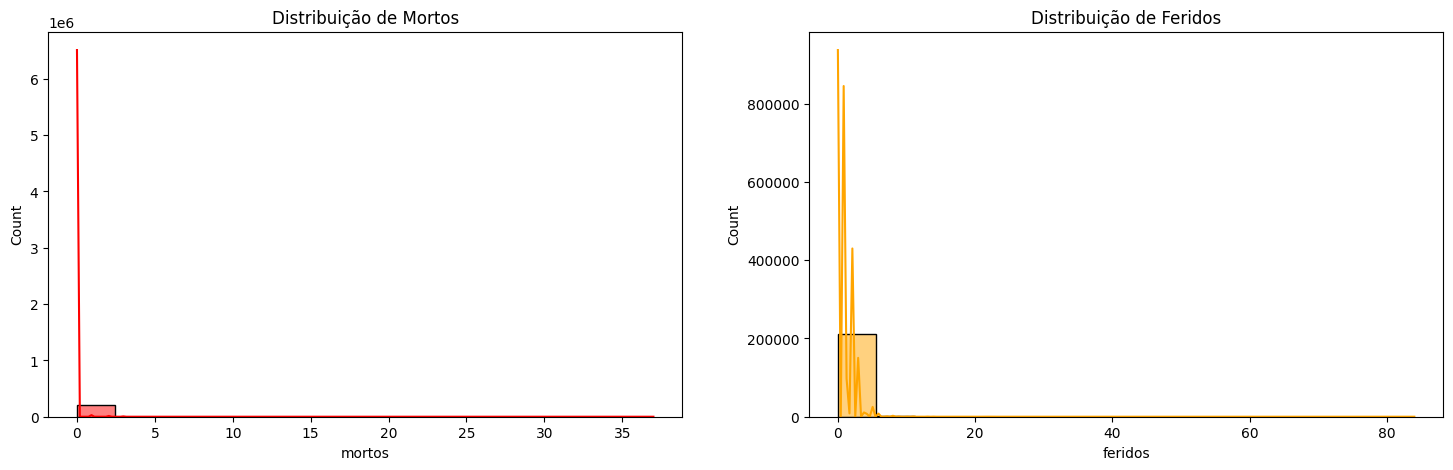

In [21]:
print(df[['mortos', 'feridos', 'km']].describe())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(df['mortos'], bins=15, ax=axes[0], kde=True, color='red')
axes[0].set_title('Distribuição de Mortos')

sns.histplot(df['feridos'], bins=15, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Distribuição de Feridos')

plt.show()

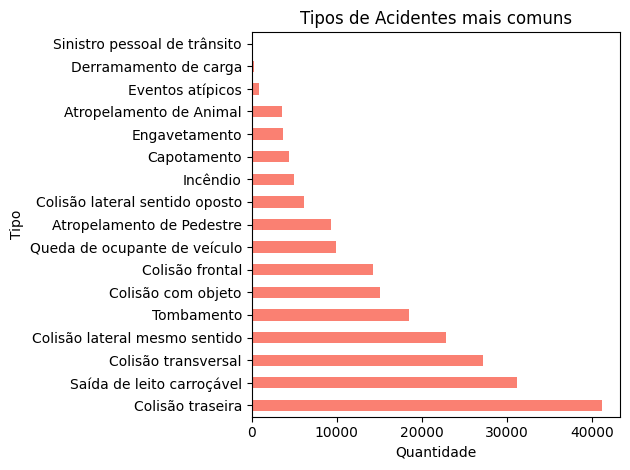

In [22]:
# Histograma para Tipo de Acidente (Horizontal)
df['tipo_acidente'].value_counts().plot(kind='barh', color='salmon')

plt.title('Tipos de Acidentes mais comuns')
plt.xlabel('Quantidade')
plt.ylabel('Tipo')
plt.tight_layout() # Ajusta o layout para não cortar o texto
plt.show()

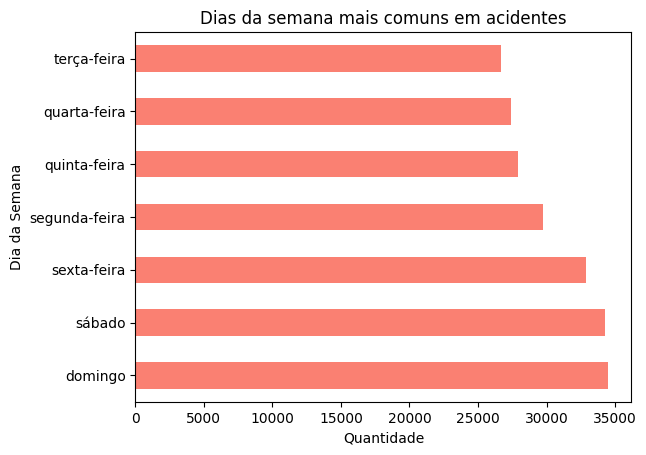

In [23]:
df['dia_semana'].value_counts().plot(kind='barh', color='salmon')

plt.title('Dias da semana mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Dia da Semana')
plt.show()

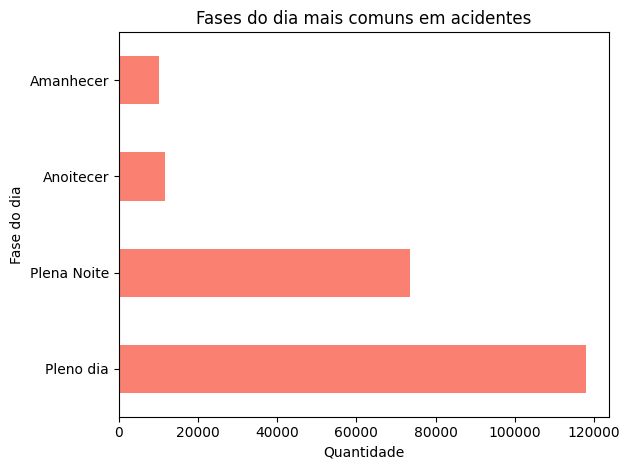

In [24]:
df['fase_dia'].value_counts().plot(kind='barh', color='salmon')

plt.title('Fases do dia mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Fase do dia')
plt.tight_layout() 
plt.show()

A maioria dos acidentes reportados aconteceram durante a tarde em dias úteis. No entanto, os acidentes graves estão majoritariamente concentrados nas sextas e finais de semana à noite

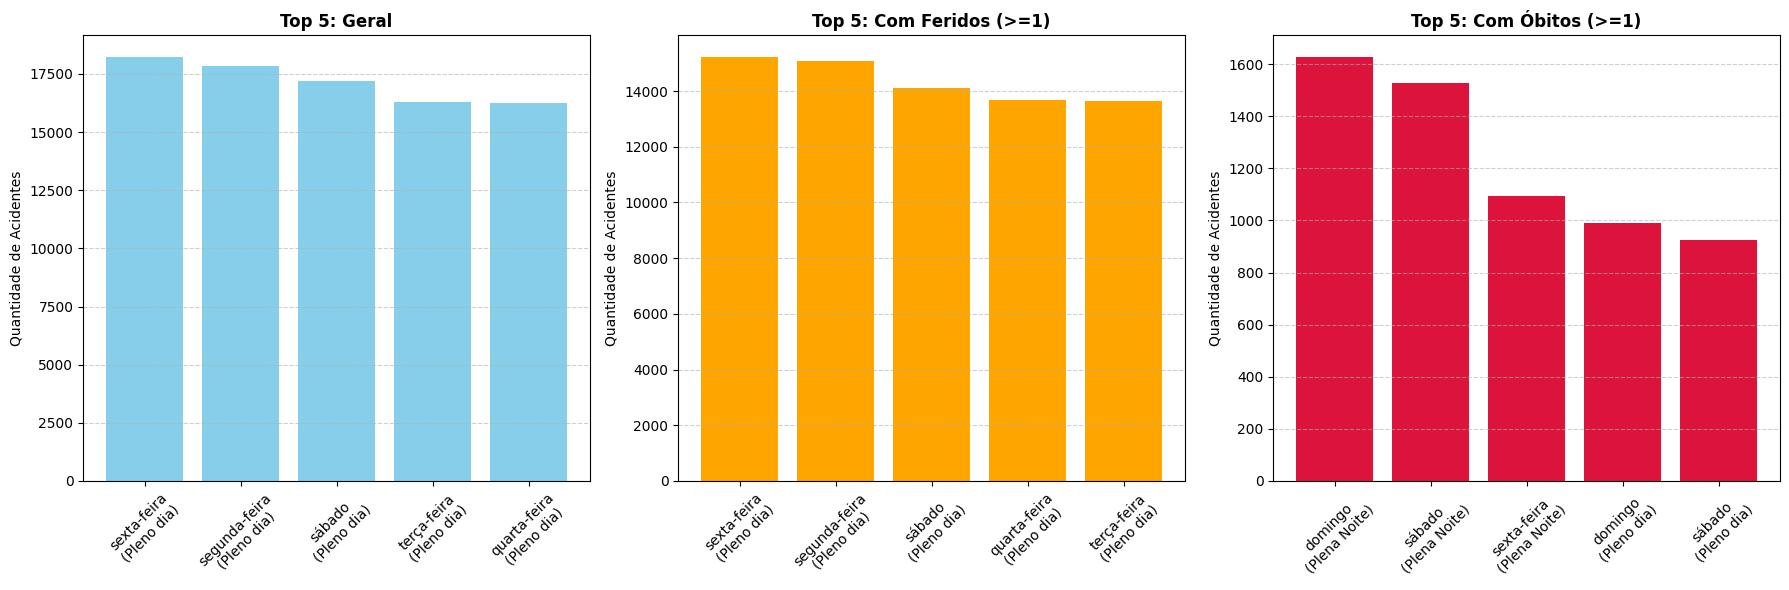

In [25]:
def pegar_top5(dataframe):
    temp = dataframe.groupby(['dia_semana', 'fase_dia']).size().reset_index(name='contagem')
    temp = temp.sort_values(by='contagem', ascending=False).head(5)
    temp['legenda'] = temp['dia_semana'] + "\n(" + temp['fase_dia'] + ")"
    return temp

df_geral = pegar_top5(df)
df_feridos = pegar_top5(df[df['feridos'] >= 1]) 
df_obitos = pegar_top5(df[df['mortos'] >= 1])   

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].bar(df_geral['legenda'], df_geral['contagem'], color='skyblue')
ax[0].set_title('Top 5: Geral', fontweight='bold')

ax[1].bar(df_feridos['legenda'], df_feridos['contagem'], color='orange')
ax[1].set_title('Top 5: Com Feridos (>=1)', fontweight='bold')

ax[2].bar(df_obitos['legenda'], df_obitos['contagem'], color='crimson')
ax[2].set_title('Top 5: Com Óbitos (>=1)', fontweight='bold')

for a in ax:
    a.tick_params(axis='x', rotation=45)
    a.set_ylabel('Quantidade de Acidentes')
    a.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

### Boxplot

Os plots de **mortos** e **feridos** contém grande concentração próximas de zero, indicando que a grande maioria dos registros não causaram óbito ou ferimento. Ambos também apresentam grande quantidade de outliers.

A análise do boxplot de **mortos** demonstra que apesar dos acidentes com vítimas serem exceção, podem atingir uma grande proporção de vítimas quando ocorrem.

No caso de **feridos**, há uma concentração maior de ocorrências de cerca de um a quarenta feridos. Com o caso mais extremo constando 80 feridos.

Já a análise da **quilometragem** demonstra que metade dos registros ocorreu antes dos 200km rodados, e a outra metade depois. A maior parte dos eventos ocorre entre 100 e 400km. Mas apesar de haver uma forte concentração de dados no início das rodovias, a base de dados cobre acidentes ocorridos em maiores extensões, chegando a trechos mais remotos

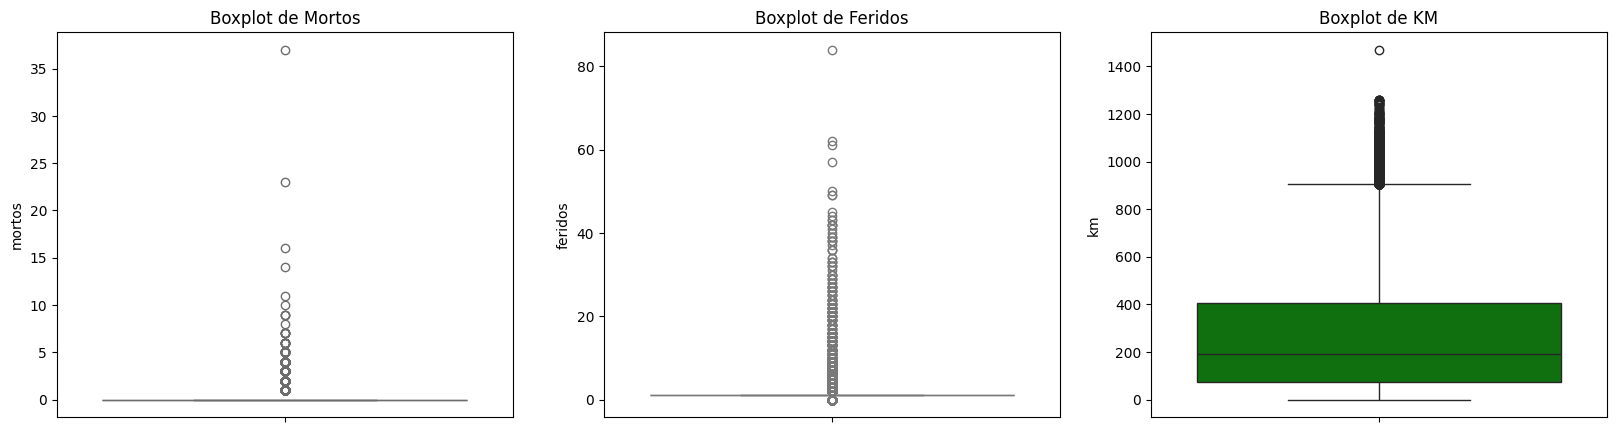

In [26]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, y='mortos', color='salmon')
plt.title('Boxplot de Mortos')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, y='feridos', color='lightblue')
plt.title('Boxplot de Feridos')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, y='km', color='green')
plt.title('Boxplot de KM')

plt.show()

### Rankeamento de acidentes graves

In [27]:
print("Acidentes com maior número de óbitos:")
display(df.nlargest(5, 'mortos'))

print("Acidentes com maior número de feridos:")
display(df.nlargest(5, 'feridos'))

Acidentes com maior número de óbitos:


,dia_semana,km,causa_acidente,tipo_acidente,fase_dia,mortos,feridos,capital
86272,sábado,286.5,Carga excessiva e/ou mal acondicionada,Colisão lateral sentido oposto,Plena Noite,37,13,0
68690,domingo,385.9,Transitar na contramão,Colisão frontal,Plena Noite,23,9,0
204845,sexta-feira,127.0,Velocidade Incompatível,Saída de leito carroçável,Plena Noite,16,21,0
85803,domingo,0.0,Demais falhas na via,Queda de ocupante de veículo,Pleno dia,14,1,0
151791,sexta-feira,648.0,Mal súbito do condutor,Colisão frontal,Plena Noite,11,42,0


Acidentes com maior número de feridos:


,dia_semana,km,causa_acidente,tipo_acidente,fase_dia,mortos,feridos,capital
86251,quarta-feira,260.0,Reação tardia ou ineficiente do condutor,Colisão com objeto,Plena Noite,5,84,0
2963,sexta-feira,550.0,Transitar na contramão,Colisão frontal,Plena Noite,3,62,0
14996,quarta-feira,138.4,Ausência de reação do condutor,Colisão traseira,Plena Noite,0,61,0
140902,sexta-feira,678.9,Velocidade Incompatível,Saída de leito carroçável,Plena Noite,4,57,0
54666,quinta-feira,15.0,Velocidade Incompatível,Saída de leito carroçável,Plena Noite,2,50,0


### Matriz de Correlação

Foi observado que não há ocorrência de variáveis altamente correlacionadas dentre os atributos que escolhemos para prosseguir a análise. Dessa forma, a redução de redundância não se fez necessária.

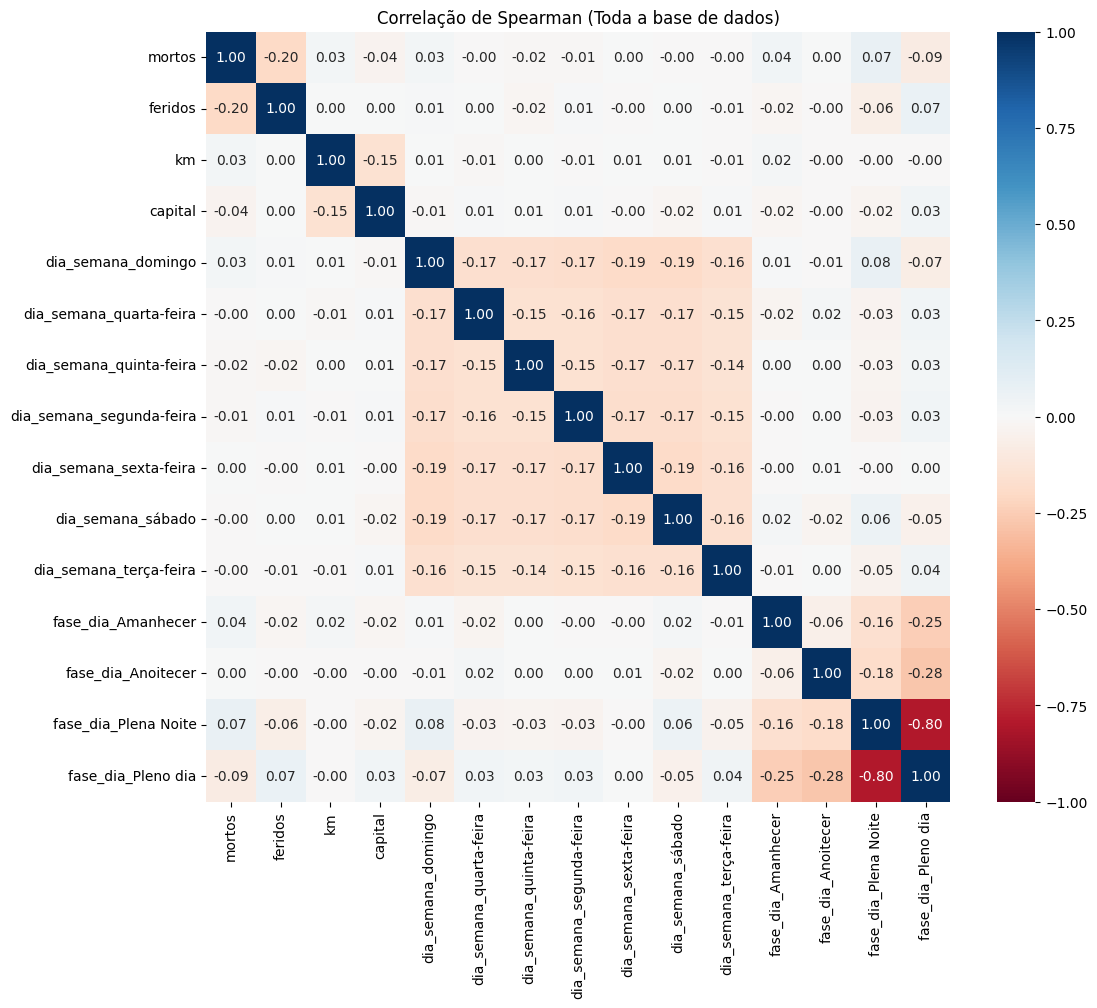

In [28]:
# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos', 'km', 'capital'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c]
corr_com_vitimas = df_encoded[colunas_interesse].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_com_vitimas, annot=True, cmap='RdBu', center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman (Toda a base de dados)')
plt.show()

#### Análise Para Acidentes Graves
Foi feita uma filtragem para entender qual a relação dos atributos com os acidentes que obtiveram ao menos um ferido e/ou um óbito. A matriz indica que não há grande correlação dos atributos com a gravidade do acidente. 

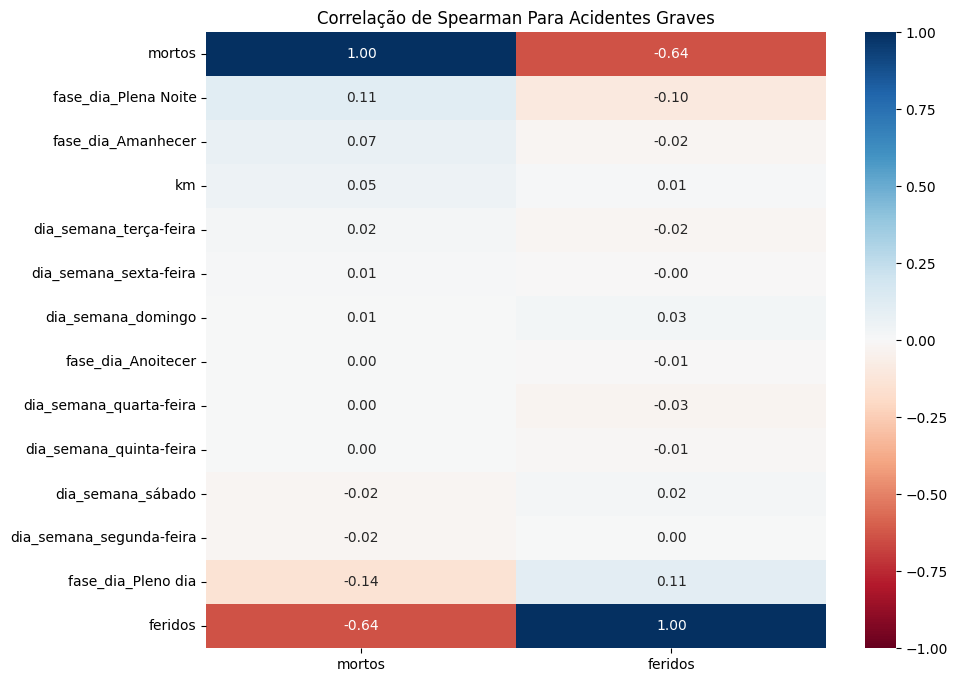

In [29]:
df_com_vitimas = df_encoded[df_encoded['mortos'] + df_encoded['feridos'] > 0].copy()

# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos', 'km'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c]
corr_com_vitimas = df_com_vitimas[colunas_interesse].corr(method='spearman')

plt.figure(figsize=(10, 8))
# Verificando a correlação de todas as variáveis apenas contra 'mortos' e 'feridos'
target_corr = corr_com_vitimas[['mortos', 'feridos']].sort_values(by='mortos', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman Para Acidentes Graves')
plt.show()